In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [2]:
# Define State
class BillState(TypedDict):
    units: int
    bill: float
    result: str

In [3]:
# Case 1: units <= 100
def case1(state: BillState):
    bill = state["units"] * 5
    return {"bill": bill, "result": f"Units {state['units']} → Bill = {bill}"}

In [4]:
# Case 2: units <= 200
def case2(state: BillState):
    bill = (100 * 5) + (state["units"] - 100) * 7
    return {"bill": bill, "result": f"Units {state['units']} → Bill = {bill}"}

In [5]:
# Case 3: units > 200
def case3(state: BillState):
    bill = (100 * 5) + (100 * 7) + (state["units"] - 200) * 10
    return {"bill": bill, "result": f"Units {state['units']} → Bill = {bill}"}

In [6]:
# Condition Function
def check_units(state: BillState) -> Literal["case1", "case2", "case3"]:
    if state["units"] <= 100:
        return "case1"
    elif state["units"] <= 200:
        return "case2"
    else:
        return "case3"

In [7]:
# Build Graph
graph = StateGraph(BillState)

graph.add_node("case1", case1)
graph.add_node("case2", case2)
graph.add_node("case3", case3)

# Edges
graph.add_conditional_edges(START, check_units)
graph.add_edge("case1", END)
graph.add_edge("case2", END)
graph.add_edge("case3", END)

In [8]:
# Compile workflow
workflow = graph.compile()

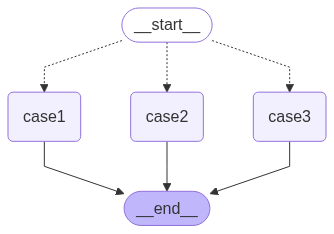

In [9]:
# Draw the Graph
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [10]:
# Example Runs
print("\n--- Run 1 ---")
print(workflow.invoke({"units": 80}))


--- Run 1 ---
{'units': 80, 'bill': 400, 'result': 'Units 80 → Bill = 400'}


In [11]:
print("\n--- Run 2 ---")
print(workflow.invoke({"units": 150}))



--- Run 2 ---
{'units': 150, 'bill': 850, 'result': 'Units 150 → Bill = 850'}


In [12]:
print("\n--- Run 3 ---")
print(workflow.invoke({"units": 250}))


--- Run 3 ---
{'units': 250, 'bill': 1700, 'result': 'Units 250 → Bill = 1700'}
